The data for this is in the sup data 1 from the paper

In [2]:
%matplotlib inline

In [3]:
import stream as st

/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
st.__version__

'1.1'

In [ ]:
adata=st.read(file_name='/Users/alicedecugis/Desktop/hematopoiesis/data/Nestorowa_2016/data_Nestorowa.tsv.gz')
data = 

/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


Using default working directory.
Saving results in: /Users/alicedecugis/Desktop/hematopoiesis/stream_result


In [6]:
st.add_cell_labels(adata,file_name='/Users/alicedecugis/Desktop/hematopoiesis/data/Nestorowa_2016/cell_label.tsv.gz')
st.add_cell_colors(adata,file_name='/Users/alicedecugis/Desktop/hematopoiesis/data/Nestorowa_2016/cell_label_color.tsv.gz')

In [7]:
st.filter_features(
    adata,
    min_n_cells=max(5, int(round(adata.shape[0] * 0.001))),
    assay="rna"
)

Filter genes based on min_n_cells
After filtering out low-expressed genes: 
1656 cells, 4764 genes


239 variable genes are selected


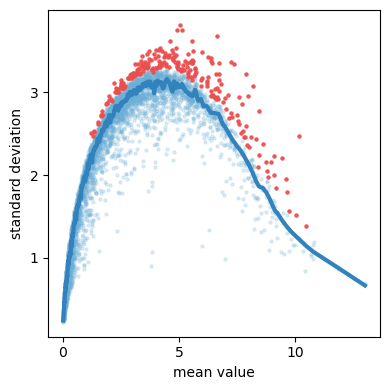

In [ ]:
st.select_variable_genes(adata)

data = 

Add Cell labels to the data

In [9]:
import pandas as pd

cell_labels = pd.read_csv(
    "/Users/alicedecugis/Desktop/hematopoiesis/data/Nestorowa_2016/cell_label.tsv.gz",
    sep="\t",
    header=None,
    names=["cell_type"]
)

print(cell_labels.shape)

(1656, 1)


In [10]:
cell_label_color = pd.read_csv(
    "/Users/alicedecugis/Desktop/hematopoiesis/data/Nestorowa_2016/cell_label_color.tsv.gz",
    sep="\t"
)

print(cell_label_color.head())
print(cell_label_color.columns.tolist())

    HSC  #40bdbd
0   MPP  #eea113
1   CMP  #d84f40
2   GMP  #10b460
3   MEP  #286ee1
4  LMPP  #7c5246
['HSC', '#40bdbd']


In [11]:
adata.obs["cell_type"] = cell_labels["cell_type"].values
print(adata.obs[["cell_type"]].head(10))

           cell_type
HSPC_025         MPP
HSPC_031         MPP
HSPC_037         MPP
LT-HSC_001       HSC
HSPC_001         MPP
HSPC_008        LMPP
HSPC_014         MPP
HSPC_020         HSC
HSPC_026        LMPP
HSPC_038         MPP


In [12]:
st.dimension_reduction(adata)

feature var_genes is being used ...
1 cpus are being used ...


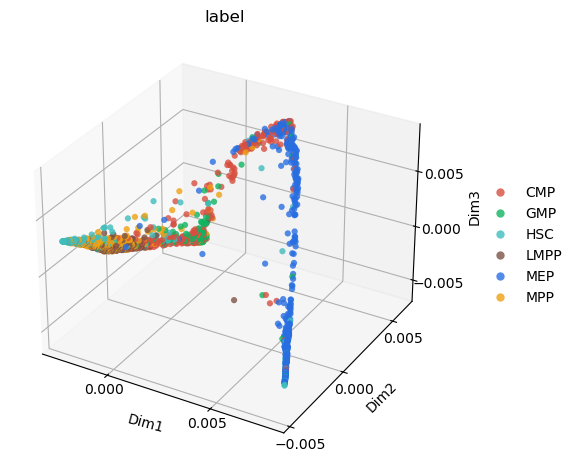

In [13]:
st.plot_dimension_reduction(adata)

In [29]:
import networkx as nx

nx.Graph.node = property(lambda G: G._node)
nx.DiGraph.node = property(lambda G: G._node)
nx.MultiGraph.node = property(lambda G: G._node)
nx.MultiDiGraph.node = property(lambda G: G._node)

print(nx.__version__)
print("G.node compatibility:", hasattr(nx.Graph(), "node"))

st.seed_elastic_principal_graph(adata)

print(adata.obsm["X_dr"].shape)
print(adata.obsm["X_dr"][:3])

2.5
G.node compatibility: True
Seeding initial elastic principal graph...
Clustering...
K-Means clustering ...
The number of initial nodes is 10
Calculatng minimum spanning tree...
Number of initial branches: 3
(1656, 3)
[[-2.34826292e-03 -1.47853803e-03 -4.19097248e-04]
 [-2.34682151e-03 -1.75185878e-03 -9.38168611e-05]
 [-2.37409489e-03 -1.32937697e-03 -7.49891258e-04]]


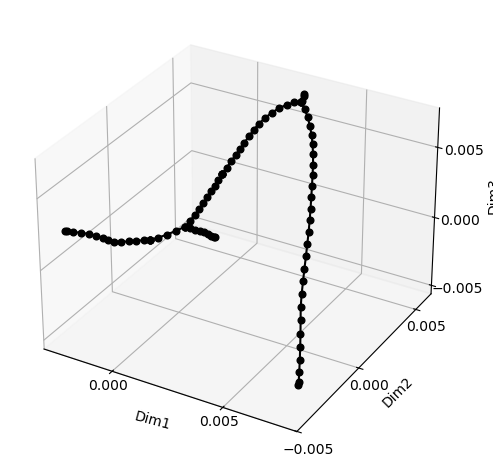

In [27]:
st.plot_branches(adata)


In [28]:
st.plot_branches_with_cells(adata)

AttributeError: module 'stream' has no attribute 'plot_branches_with_cells'

In [16]:
st.elastic_principal_graph(adata)

Learning elastic principal graph...
[1] "Constructing tree 1 of 1 / Subset 1 of 1"
[1] "Computing EPG with 50 nodes on 1656 points and 3 dimensions"
[1] "Using a single core"
Nodes = 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 
BARCODE	ENERGY	NNODES	NEDGES	NRIBS	NSTARS	NRAYS	NRAYS2	MSE	MSEP	FVE	FVEP	UE	UR	URN	URN2	URSD
5||50	1.117e-06	50	49	38	5	0	0	4.073e-07	3.78e-07	0.9889	0.9897	6.617e-07	4.783e-08	2.391e-06	0.0001196	0
8.484 sec elapsed
[[1]]
Ignoring unknown labels:
• linetype : ""

TYPE epg_obj: <class 'rpy2.rlike.container.NamedList'>
TYPE epg_obj[0]: <class 'rpy2.rlike.container.NamedList'>
epg_obj[0]: <rpy2.rlike.container.NamedList object at 0x1697fd9f0>
NAMES epg_obj[0]: <bound method NamedList.names of <rpy2.rlike.container.NamedList object at 0x1697fd9f0>>
Number of branches after learning elastic principal graph: 11


/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/stream/core.py:1455: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  adata.uns[ann+'_color'] = {df_plot_shuf[ann][i]:'#%02x%02x%02x' % (colors_sns_scaled[i][0], colors_sns_scaled[i][1], colors_sns_scaled[i][2])


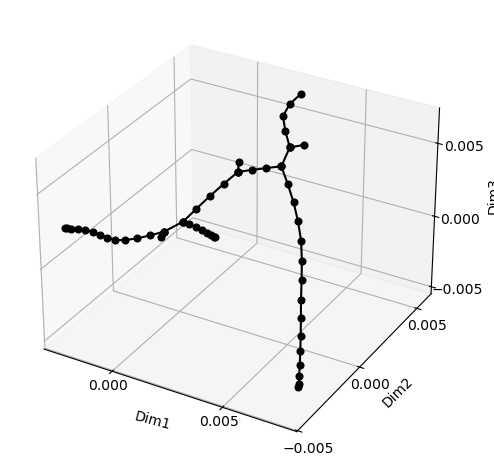

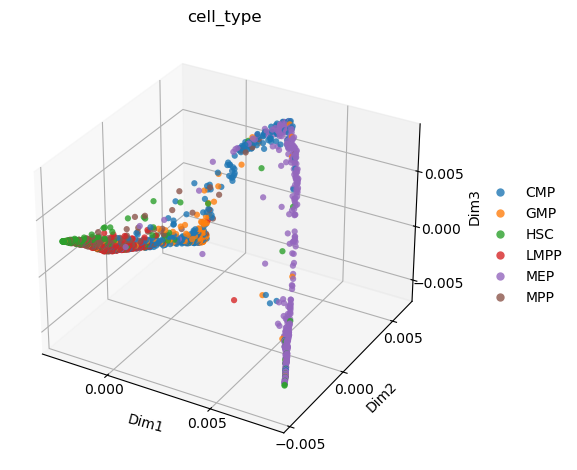

In [17]:
st.plot_branches(adata)
st.plot_dimension_reduction(
    adata,
    color=["cell_type"],
    show_graph=False,
    show_text=False
)

Optimizing branching...
[1] "Constructing tree 1 of 1 / Subset 1 of 1"
[1] "Computing EPG with 80 nodes on 1656 points and 3 dimensions"
[1] "Using a single core"
Nodes = 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 
BARCODE	ENERGY	NNODES	NEDGES	NRIBS	NSTARS	NRAYS	NRAYS2	MSE	MSEP	FVE	FVEP	UE	UR	URN	URN2	URSD
1|3||80	6.974e-07	80	79	69	3	0	0	2.446e-07	2.255e-07	0.9933	0.9939	4.294e-07	2.348e-08	1.878e-06	0.0001503	0
3.799 sec elapsed
Number of branches after optimizing branching: 10


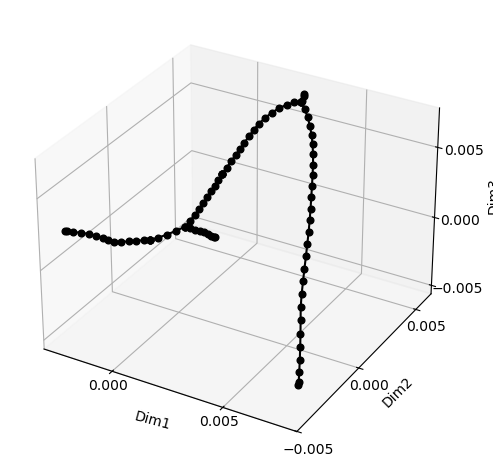

In [18]:
st.optimize_branching(adata,reset=True)
st.plot_branches(adata)


Extending leaves with additional nodes ...
Number of branches after extending leaves: 10


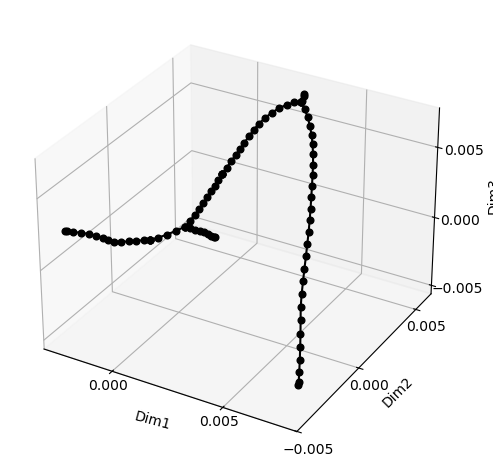

In [25]:
st.extend_elastic_principal_graph(adata)
st.plot_branches(adata)


In [20]:
import stream.extra

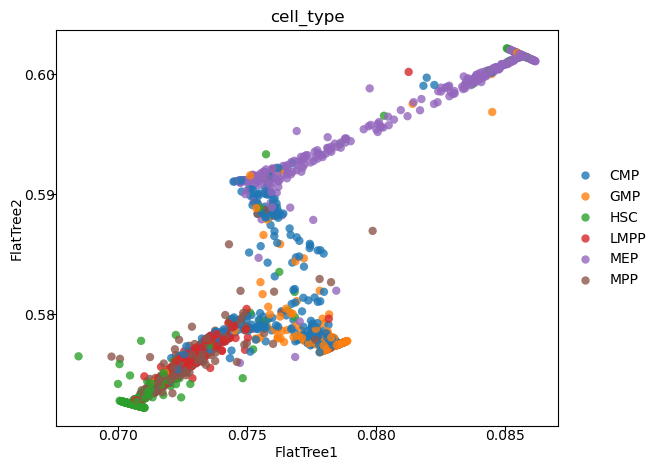

In [21]:
st.plot_flat_tree(
    adata,
    color=["cell_type"]
)

/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


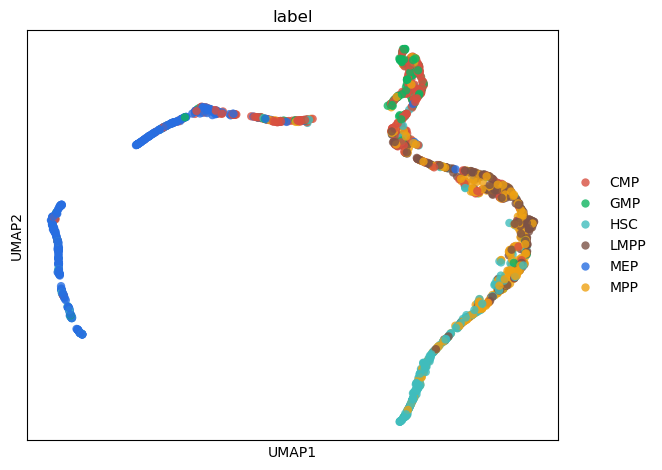

In [22]:
st.plot_visualization_2D(adata,use_precomputed=False)

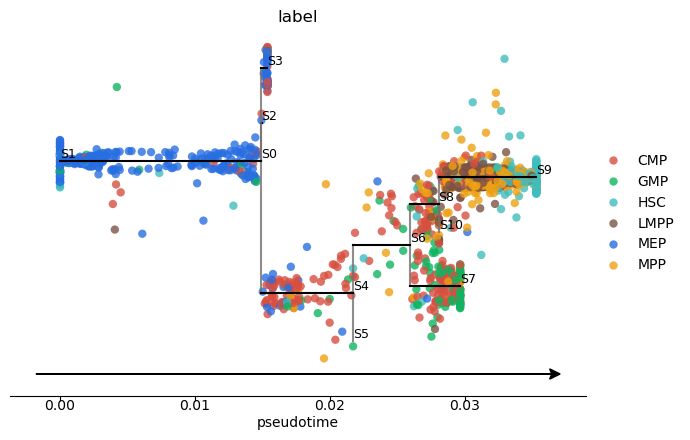

In [23]:
st.plot_stream_sc(
    adata,
    root="S1"
)

#### The order between horizontal branches from the same parent node has no meaning

#### Users can specify the order preference of nodes themselves

In [24]:
st.subwaymap_plot(adata,percentile_dist=100,root='S1',fig_legend_ncol=6,preference=['S4','S5']) 

AttributeError: module 'stream' has no attribute 'subwaymap_plot'

Save the cluster list

In [ ]:
print(adata.obs.columns.tolist())

for col in ["kmeans", "node"]:
    if col in adata.obs.columns:
        print("\n", col)
        print(adata.obs[col].value_counts())

stream_clusters = adata.obs[["kmeans"]].copy()

stream_clusters.to_csv(
    "/Users/alicedecugis/Desktop/hematopoiesis/data/nestorowa_STREAM_clusters.csv"
)

['label', 'cell_type', 'kmeans', 'node', 'branch_id', 'branch_id_alias', 'branch_lam', 'branch_dist', 'S0_pseudotime', 'S6_pseudotime', 'S2_pseudotime', 'S3_pseudotime', 'S7_pseudotime', 'S10_pseudotime', 'S9_pseudotime', 'S1_pseudotime', 'S4_pseudotime', 'S5_pseudotime', 'S8_pseudotime']

 kmeans
kmeans
cluster 0    334
cluster 9    317
cluster 2    197
cluster 4    188
cluster 6    162
cluster 1    152
cluster 7    110
cluster 8     76
cluster 3     66
cluster 5     54
Name: count, dtype: int64

 node
node
44    131
0     108
9      82
45     74
13     69
     ... 
38      2
16      2
59      2
30      1
1       1
Name: count, Length: 78, dtype: int64
